Modelo S sem data augmentation

In [4]:
# dependencies
from keras.utils import image_dataset_from_directory
from tensorflow import keras
from keras import layers
import matplotlib.pyplot as plt
from keras import layers, regularizers
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.preprocessing import image
import numpy as np

In [5]:
train_dir = 'train'
validation_dir = 'validation'
test_dir = 'test'

IMG_SIZE = 32

train_dataset = image_dataset_from_directory(train_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32) 
validation_dataset = image_dataset_from_directory(validation_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32)
test_dataset = image_dataset_from_directory(test_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32)

Found 40000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


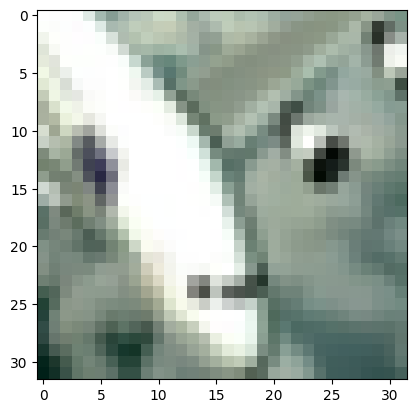

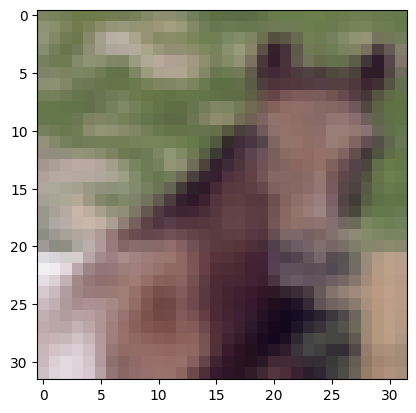

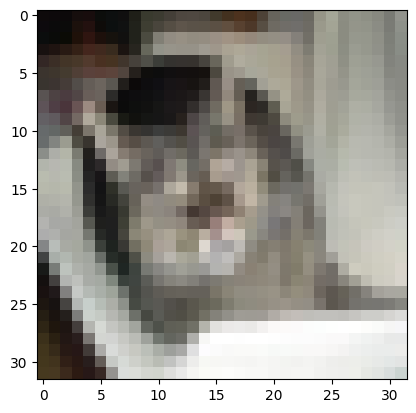

In [3]:
# import matplotlib.pyplot as plt

for data_batch, _ in train_dataset.take(1):
  for i in range(3):
    plt.imshow(data_batch[i].numpy().astype("uint8"))
    plt.show()

In [12]:
inputs = keras.Input(shape=(32, 32, 3))

l2_regularizer = 0.001

x = layers.Conv2D(filters=50, kernel_size=3, activation="relu")(inputs)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=100, kernel_size=3, activation="relu", kernel_regularizer=regularizers.L2(l2_regularizer))(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Dropout(0.25)(x)

x = layers.Conv2D(filters=100, kernel_size=3, activation="relu", kernel_regularizer=regularizers.L2(l2_regularizer))(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Flatten()(x)

x = layers.Dropout(0.5)(x)
x = layers.Dense(100, activation="relu")(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(25, activation="relu")(x)
outputs = layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 100)    │        45,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 100)      │        90,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        40,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │         2,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179,485 (701.11 KB)

 Trainable params: 179,485 (701.11 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(loss='sparse_categorical_crossentropy', optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4), metrics=['acc'])

In [15]:
model_filename = 'model_s_sem_optuna_noaugm.keras'

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# para salvar o melhor modelo
checkpoint_callback = ModelCheckpoint(
    model_filename,
    monitor='val_acc', 
    save_best_only=True,
    mode='max',
    save_weights_only=False
)

# Training the model
history = model.fit(train_dataset, epochs=100, validation_data=validation_dataset, callbacks=[early_stopping, checkpoint_callback])


Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 40s 31ms/step - acc: 0.1273 - loss: 4.8818 - val_acc: 0.2550 - val_loss: 2.1214
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 28ms/step - acc: 0.2411 - loss: 2.1208 - val_acc: 0.3232 - val_loss: 1.8922
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 28ms/step - acc: 0.3111 - loss: 1.9028 - val_acc: 0.4004 - val_loss: 1.7304
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 28ms/step - acc: 0.3623 - loss: 1.7794 - val_acc: 0.4302 - val_loss: 1.6347
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - acc: 0.4148 - loss: 1.6646 - val_acc: 0.4857 - val_loss: 1.5254
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 28ms/step - acc: 0.4455 - loss: 1.5931 - val_acc: 0.5101 - val_loss: 1.4540
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - acc: 0.4800 - loss: 1.5188 - val_acc: 0.5424 - val_loss: 1.3889
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - acc: 0.5081 - loss: 1.4478 - val_acc: 0.5715 - val_loss: 1.3122
Epoch 9/100
1250

Sem data augmentation entendemos que a accuracy de validação parou de evoluir mais cedo e que ocorreu overfitting também mais cedo do que com data Saugmentation. Isso é visível pelo facto de que em ambos com um 'patience leve' igual a 10, o Early Stopping apenas parou mais cedo no modelo sem data augmentation, realçando assim a sua importância para a criação de um bom modelo.
Esta conclusão seria de esperar pois o data augmentation é uma técnica que permite aumentar o tamanho do dataset de treino, aplicando transformações aleatórias nas imagens, como rotações, zooms, entre outras, de maneira a reduzir o overfitting.

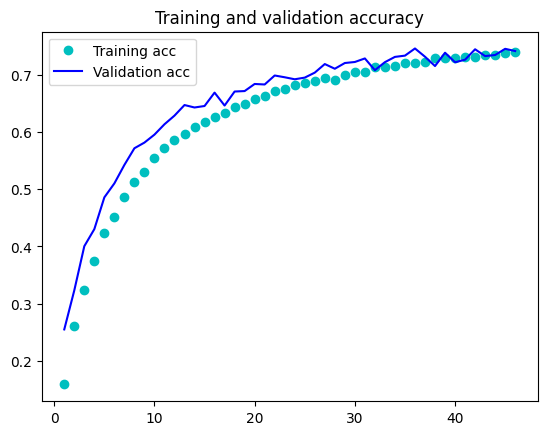

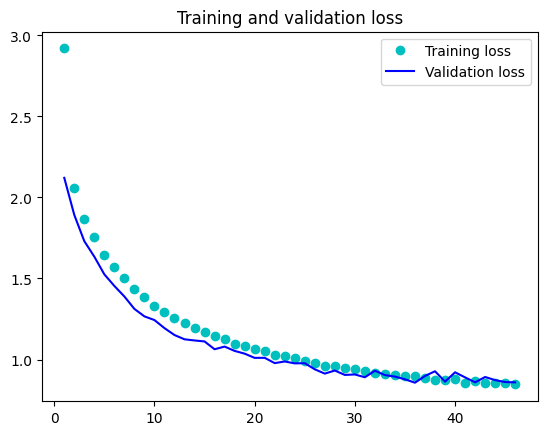

In [16]:
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'co', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'co', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

# validation acc e validation loss é a que realmente importa

In [11]:
val_loss, val_accuracy = model.evaluate(validation_dataset)
print(f'Validation Accuracy of the Best Model: {val_accuracy}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - acc: 0.7454 - loss: 0.8478
Validation Accuracy of the Best Model: 0.7444000244140625


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━

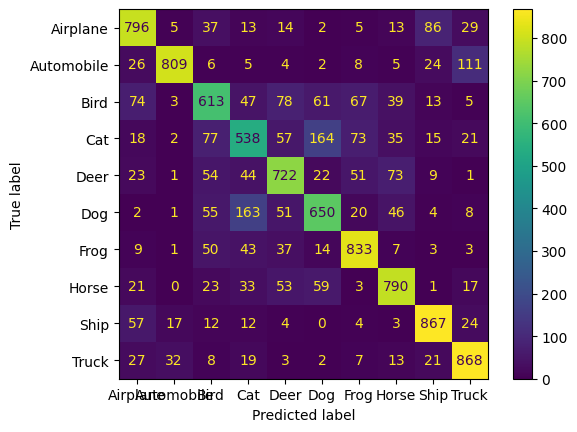

In [7]:
from sklearn import metrics
import tensorflow as tf
from tensorflow.keras.models import load_model

# Load the model
loaded_model = tf.keras.models.load_model('model_s_sem_optuna_noaugm.keras')

y_true = []
y_pred = []

# Iterate over the test dataset to get predictions and true labels
for images, labels in test_dataset:
    preds = loaded_model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Convert lists to NumPy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute the confusion matrix
conf_mat = metrics.confusion_matrix(y_true, y_pred)

# display matrix
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=["Airplane", "Automobile", "Bird", "Cat", "Deer", "Dog", "Frog", "Horse", "Ship", "Truck"])
cm_display.plot()
plt.show()


Por análise da matriz de confusão, entende-se que o modelo apresenta resultados maioritariamente satisfatórios, no entanto não tão bons como no mesmo modelo com data augmentation. 
A destacar são as classes bird e cat, que são aquelas em que o modelo apresenta maior dificuldade em classificar corretamente, tendo em 1000 imagens acertado em 613 e 538, respetivamente. 
Outro ponto a destacar é que a classe pela qual 'cat' é mais confundida é a classe 'dog' e vice-versa, revelando que o modelo tem dificuldade em distinguir entre estas duas classes. As classes com maior taxa de acerto são 'truck' e 'ship', com 868 e 867 imagens corretamente classificadas, respetivamente.
Também há bastante confusão em distinguir automobile e truck, assim como bastante confusão na zona mais central do gráfico, onde se encontram as classes 'bird', 'cat', 'deer' e 'dog'.

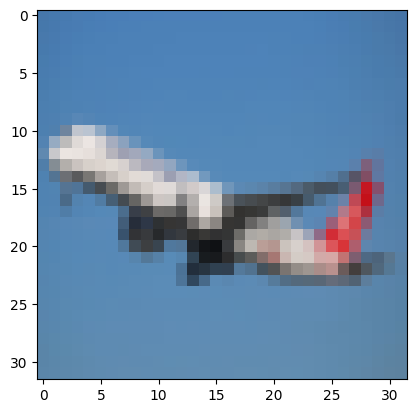

(1, 32, 32, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
Model predicts:  airplane
Result:  [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [9]:
img = tf.keras.preprocessing.image.load_img('airplane.jpg', target_size=(32, 32), interpolation='bilinear')
plt.imshow(img)
plt.show()
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)
print(img_array.shape)
result = model.predict(img_array)
whatIsIt = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

predicted_classes = result.round()
predicted_index = np.where(predicted_classes == 1)[1]

print("Model predicts: ", whatIsIt[predicted_index[0]])
print("Result: ", result.round())